# Brazilian E-Commerce Performance Analytics (Olist) — Data Cleaning
### A data analyst project

**Goal:** Take Olist's 9 real relational CSV exports (100k+ real orders
from a Brazilian e-commerce marketplace) and build a proper star schema - 4 dimension tables and 4 fact tables


## Setup

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)


## 1. Load the raw data
We load all 9 relational CSV files into DataFrames and check their dimensions to understand the relational structure.

In [ ]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

for name, d in [("customers", customers), ("geolocation", geolocation),
                ("order_items", order_items), ("payments", payments),
                ("reviews", reviews), ("orders", orders),
                ("products", products), ("sellers", sellers)]:
    print(f"{name:12s} {d.shape}")


customers    (99441, 5)
geolocation  (1000163, 5)
order_items  (112650, 7)
payments     (103886, 5)
reviews      (99224, 7)
orders       (99441, 8)
products     (32951, 9)
sellers      (3095, 4)


## 2. Build `dim_customers`

We distinguish between customer_id (order-level key) and customer_unique_id (real person key) to prevent downstream metric distortions, ensuring a 1:1 customer dimension.

In [ ]:
dim_customers = customers.drop_duplicates(subset=["customer_id"]).copy()
assert dim_customers["customer_id"].is_unique
print(dim_customers.shape)
print("Unique people (customer_unique_id):", dim_customers["customer_unique_id"].nunique())
dim_customers.head()


(99441, 5)
Unique people (customer_unique_id): 96096


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 3. Build `dim_sellers`
We deduplicate and format the seller lookup table to serve as our merchant dimension.

In [ ]:
dim_sellers = sellers.drop_duplicates(subset=["seller_id"]).copy()
assert dim_sellers["seller_id"].is_unique
print(dim_sellers.shape)
dim_sellers.head()


(3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## 4. Build `dim_products` (merged with English category names)

Product categories are stored in Portuguese, with a separate translation
table. Two category names in the products table have no matching
translation - rather than losing those products' category entirely, we
fall back to the original Portuguese name.

In [ ]:
products = products.merge(category_translation, how="left", on="product_category_name")

missing_translation = set(products["product_category_name"].dropna().unique()) - set(category_translation["product_category_name"].unique())
print("Categories with no English translation:", missing_translation)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)
products["product_category_name_english"] = (
    products["product_category_name_english"].str.replace("_", " ").str.title()
)

products["product_volume_cm3"] = (
    products["product_length_cm"] * products["product_height_cm"] * products["product_width_cm"]
)

dim_products = products[[
    "product_id", "product_category_name_english", "product_name_lenght",
    "product_description_lenght", "product_photos_qty", "product_weight_g",
    "product_length_cm", "product_height_cm", "product_width_cm", "product_volume_cm3",
]].rename(columns={
    "product_category_name_english": "category",
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length",
})
assert dim_products["product_id"].is_unique
print(dim_products.shape)
dim_products.head()


Categories with no English translation: {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}
(32951, 10)


,product_id,category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,Perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,Sports Leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,Baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,Housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0,4420.0


## 5. Build `dim_geolocation`

We clean noisy GPS data (~1M pings) by filtering out coordinates outside Brazil's bounding box and aggregating to median latitude/longitude per zip code prefix.

In [ ]:
brazil_lat = (-34, 6)
brazil_lng = (-74, -32)
geo_valid = geolocation[
    geolocation["geolocation_lat"].between(*brazil_lat) &
    geolocation["geolocation_lng"].between(*brazil_lng)
]
print(f"Dropped {len(geolocation) - len(geo_valid)} rows outside Brazil's bounding box")

dim_geolocation = (
    geo_valid.groupby("geolocation_zip_code_prefix")
    .agg(
        lat=("geolocation_lat", "median"),
        lng=("geolocation_lng", "median"),
        city=("geolocation_city", lambda s: s.mode().iat[0]),
        state=("geolocation_state", lambda s: s.mode().iat[0]),
    )
    .reset_index()
    .rename(columns={"geolocation_zip_code_prefix": "zip_code_prefix"})
)
assert dim_geolocation["zip_code_prefix"].is_unique
print(dim_geolocation.shape)
dim_geolocation.head()


Dropped 31 rows outside Brazil's bounding box
(19011, 5)


,zip_code_prefix,lat,lng,city,state
0,1001,-23.550381,-46.634027,sao paulo,SP
1,1002,-23.548551,-46.635072,sao paulo,SP
2,1003,-23.548977,-46.635313,sao paulo,SP
3,1004,-23.549535,-46.634771,sao paulo,SP
4,1005,-23.549612,-46.636532,sao paulo,SP


## 6. Build `fact_orders`

We parse timestamp fields and engineer operational delivery KPIs, such as actual delivery duration, delivery delta vs. estimation, and a boolean flag for late deliveries.

In [ ]:
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

orders["delivery_days_actual"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days
orders["delivery_days_estimated"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.days
orders["delivery_delta_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days  # positive = late, negative = early
orders["is_late"] = orders["delivery_delta_days"] > 0
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

fact_orders = orders.copy()
assert fact_orders["order_id"].is_unique
print(fact_orders["is_late"].mean(), "of delivered orders arrived late")
fact_orders[["order_status", "delivery_days_actual", "delivery_delta_days", "is_late"]].head()


0.06571736004263835 of delivered orders arrived late


,order_status,delivery_days_actual,delivery_delta_days,is_late
0,delivered,8.0,-8.0,False
1,delivered,13.0,-6.0,False
2,delivered,9.0,-18.0,False
3,delivered,13.0,-13.0,False
4,delivered,2.0,-10.0,False


## 7. Build `fact_order_items`, `fact_payments`, `fact_reviews`

We build line-item, payment, and review fact tables, calculating total item costs, response latency, and extracting boolean indicators for written review comments.

In [ ]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])
order_items["item_total"] = order_items["price"] + order_items["freight_value"]
fact_order_items = order_items.copy()
fact_order_items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [ ]:
fact_payments = payments.copy()
fact_payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])
reviews["response_time_days"] = (
    reviews["review_answer_timestamp"] - reviews["review_creation_date"]
).dt.days
reviews["has_comment"] = reviews["review_comment_message"].notna()
fact_reviews = reviews.drop(columns=["review_comment_title", "review_comment_message"])
fact_reviews.head()


,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,response_time_days,has_comment
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,0,False
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,1,False
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,1,False
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,0,True
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,1,True


## 8. Referential integrity checks
We validate foreign key relationships across the entire star schema to ensure seamless SQL joins.

In [ ]:
assert fact_orders["customer_id"].isin(dim_customers["customer_id"]).all()
assert fact_order_items["order_id"].isin(fact_orders["order_id"]).all()
assert fact_order_items["product_id"].isin(dim_products["product_id"]).all()
assert fact_order_items["seller_id"].isin(dim_sellers["seller_id"]).all()
assert fact_payments["order_id"].isin(fact_orders["order_id"]).all()
assert fact_reviews["order_id"].isin(fact_orders["order_id"]).all()
print("All referential integrity checks passed.")


All referential integrity checks passed.


## 9. Exploratory data analysis charts
A brief exploratory check into monthly order trends and customer review score distributions.

<Axes: title={'center': 'Orders per Month'}, xlabel='order_month'>

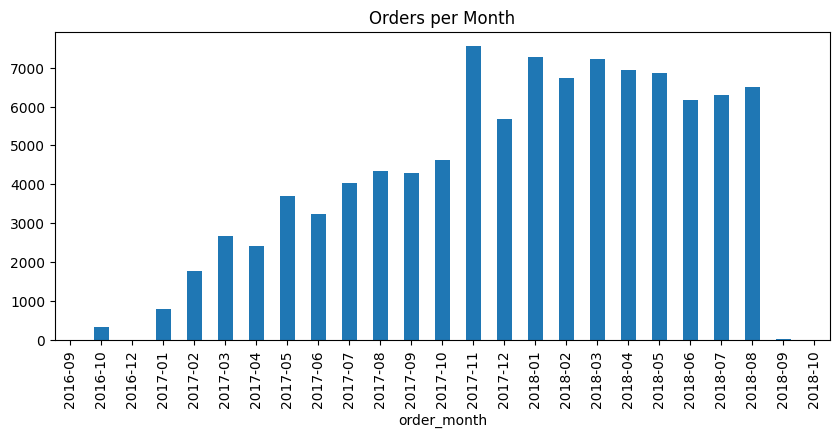

In [ ]:
fact_orders.groupby("order_month").size().plot(
    kind="bar", title="Orders per Month", figsize=(10,4))


<Axes: title={'center': 'Review Score Distribution'}, xlabel='review_score'>

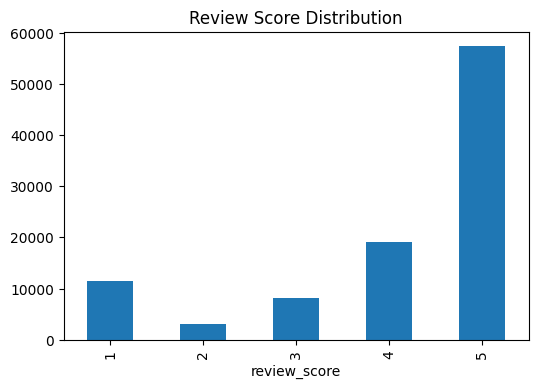

In [ ]:
fact_reviews["review_score"].value_counts().sort_index().plot(
    kind="bar", title="Review Score Distribution", figsize=(6,4))


## 10. Export the star schema
Exporting all 4 dimension and 4 fact tables to clean CSV files for reporting

In [ ]:
dim_customers.to_csv("dim_customers.csv", index=False)
dim_sellers.to_csv("dim_sellers.csv", index=False)
dim_products.to_csv("dim_products.csv", index=False)
dim_geolocation.to_csv("dim_geolocation.csv", index=False)
fact_orders.to_csv("fact_orders.csv", index=False)
fact_order_items.to_csv("fact_order_items.csv", index=False)
fact_payments.to_csv("fact_payments.csv", index=False)
fact_reviews.to_csv("fact_reviews.csv", index=False)